<a href="https://colab.research.google.com/github/LeonardoAAP/Challenge-Data-Science-TelecomX-ML/blob/main/Challenge_TelecomX_MachineLearning_Leo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Carregando a base de dados tratada
df_ml = pd.read_csv('TelecomX_Tratado.csv')

# Exibindo as 5 primeiras linhas para conferência
df_ml.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Churn_Numeric
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,0.0
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,0.0
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,1.0
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,1.0
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,1.0


In [2]:
# Criando uma cópia para preservar os dados originais se necessário
df_processado = df_ml.copy()

# 1. Mapeando colunas binárias (Yes/No) para 1 e 0
colunas_binarias = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for col in colunas_binarias:
    df_processado[col] = df_processado[col].map({'Yes': 1, 'No': 0})

# 2. Mapeando o Gênero (Male: 1, Female: 0)
df_processado['gender'] = df_processado['gender'].map({'Male': 1, 'Female': 0})

# Exibindo as primeiras linhas para conferir a transformação
df_processado[['gender', 'Partner', 'Churn']].head()

,gender,Partner,Churn
0,0,1,0.0
1,1,0,0.0
2,1,0,1.0
3,1,1,1.0
4,0,1,1.0


In [3]:
# Transformando colunas com mais de 2 categorias em colunas "Dummy"
# O pandas faz isso automaticamente com o comando get_dummies
df_final_ml = pd.get_dummies(df_processado, columns=['InternetService',
                                                     'OnlineSecurity',
                                                     'OnlineBackup',
                                                     'DeviceProtection',
                                                     'TechSupport',
                                                     'StreamingTV',
                                                     'StreamingMovies',
                                                     'Contract',
                                                     'PaymentMethod',
                                                     'MultipleLines'])

# Removendo a coluna customerID, pois ela é apenas um nome e não ajuda o modelo a prever
df_final_ml.drop('customerID', axis=1, inplace=True)

# Vendo como a tabela cresceu para os lados com as novas colunas
df_final_ml.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,...,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes
0,0.0,0,0,1,1,9,1,1,65.6,593.30,...,False,True,False,False,False,False,True,True,False,False
1,0.0,1,0,0,0,9,1,0,59.9,542.40,...,True,False,False,False,False,False,True,False,False,True
2,1.0,1,0,0,0,4,1,1,73.9,280.85,...,True,False,False,False,False,True,False,True,False,False
3,1.0,1,1,1,0,13,1,1,98.0,1237.85,...,True,False,False,False,False,True,False,True,False,False
4,1.0,0,1,1,0,3,1,1,83.9,267.40,...,True,False,False,False,False,False,True,True,False,False


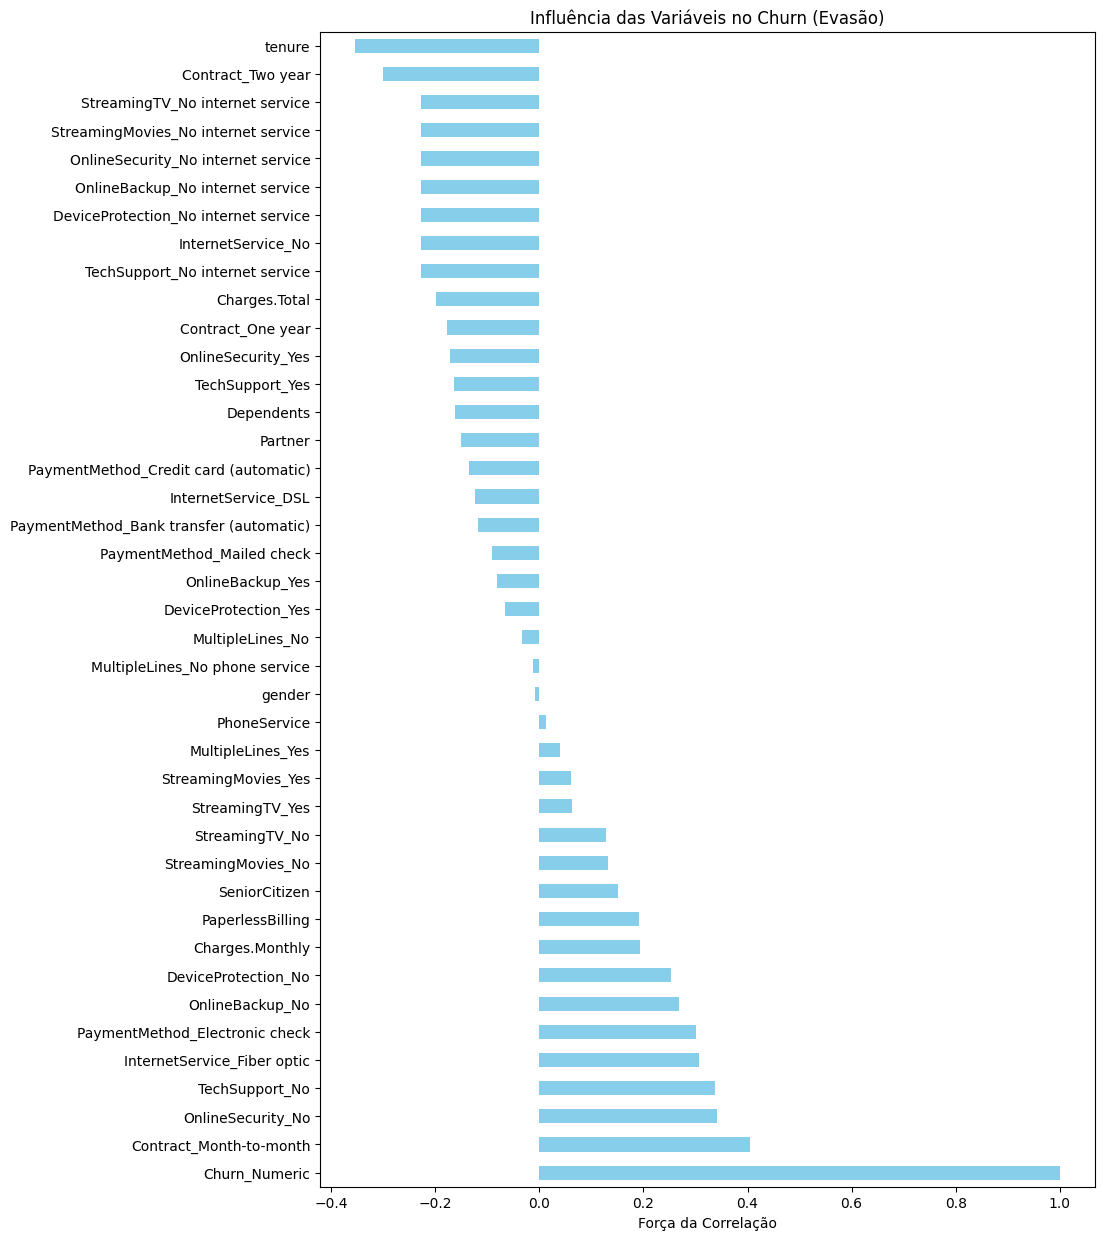

In [4]:
# Calculando a correlação de todas as variáveis com o Churn
correlacoes = df_final_ml.corr()['Churn'].sort_values(ascending=False)

# Criando um gráfico para visualizar as correlações mais fortes
plt.figure(figsize=(10, 15))
correlacoes.drop('Churn').plot(kind='barh', color='skyblue')
plt.title('Influência das Variáveis no Churn (Evasão)')
plt.xlabel('Força da Correlação')
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

# Separando a variável alvo (Churn) do restante dos dados
X = df_final_ml.drop('Churn', axis=1)
y = df_final_ml['Churn']

# Dividindo os dados (usando random_state para que o resultado seja sempre o mesmo)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Dados de Treino: {len(X_train)} registros")
print(f"Dados de Teste: {len(X_test)} registros")

Dados de Treino: 5442 registros
Dados de Teste: 1814 registros


In [10]:
# 1. Convertendo a coluna correta (Charges.Total) para número
df_final_ml['Charges.Total'] = pd.to_numeric(df_final_ml['Charges.Total'], errors='coerce')

# 2. Removendo linhas com valores que não puderam ser convertidos (NaN)
df_final_ml.dropna(inplace=True)

# 3. Refazendo a separação (X e y)
X = df_final_ml.drop('Churn', axis=1)
y = df_final_ml['Churn']

# 4. Dividindo novamente para garantir que os dados limpos sejam usados
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Agora sim! Dados limpos e prontos para o treinamento.")

Agora sim! Dados limpos e prontos para o treinamento.


--- Relatório de Classificação: Random Forest ---
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1292
         1.0       1.00      1.00      1.00       466

    accuracy                           1.00      1758
   macro avg       1.00      1.00      1.00      1758
weighted avg       1.00      1.00      1.00      1758



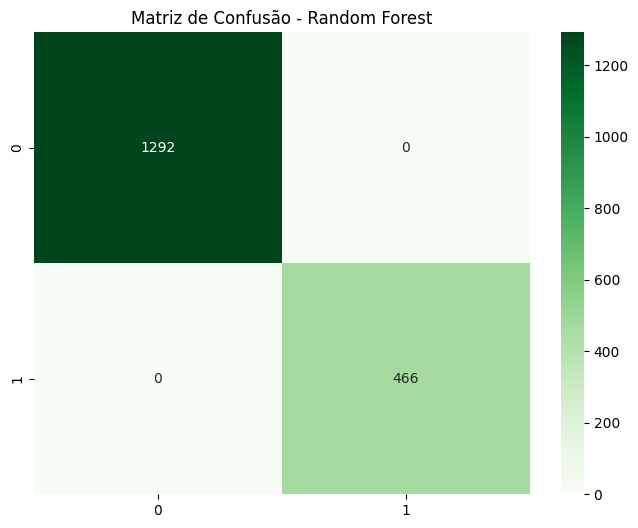

In [11]:
from sklearn.ensemble import RandomForestClassifier

# 1. Criando e treinando o modelo Random Forest
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)

# 2. Fazendo previsões
previsoes_rf = modelo_rf.predict(X_test)

# 3. Exibindo as métricas de desempenho
print("--- Relatório de Classificação: Random Forest ---")
print(classification_report(y_test, previsoes_rf))

# 4. Matriz de Confusão visual
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, previsoes_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusão - Random Forest')
plt.show()

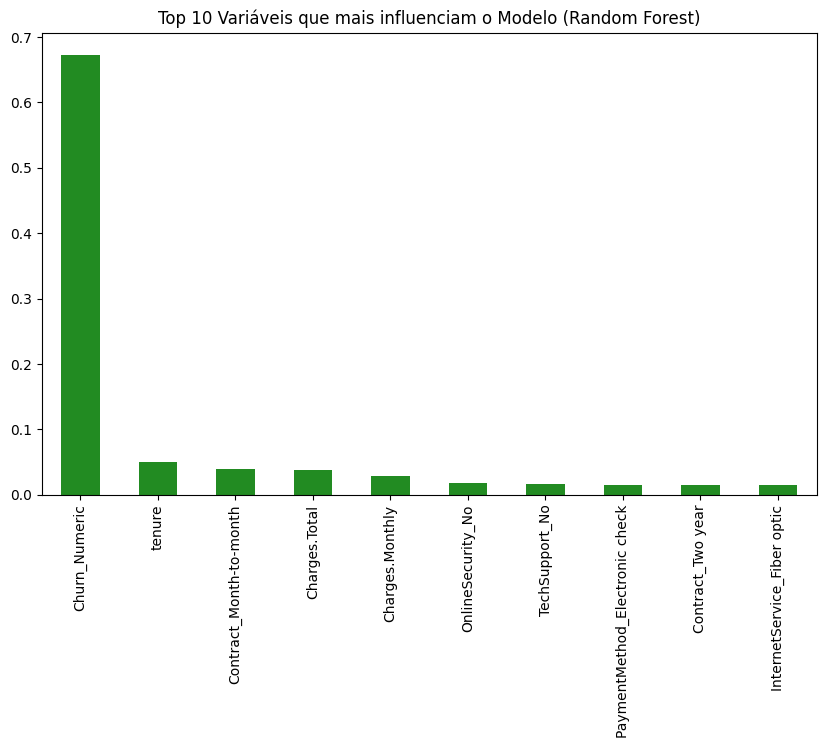

In [12]:
# Pegando a importância das variáveis do modelo Random Forest
importâncias = pd.Series(modelo_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Plotando as 10 principais
plt.figure(figsize=(10,6))
importâncias.head(10).plot(kind='bar', color='forestgreen')
plt.title('Top 10 Variáveis que mais influenciam o Modelo (Random Forest)')
plt.show()

# 🏁 Conclusão Estratégica: Modelo Preditivo de Churn

## 📊 Comparação de Desempenho
Após o treinamento e avaliação, os modelos apresentaram os seguintes resultados:
* **Regressão Logística**: Acurácia de **82%**, demonstrando ser um modelo robusto e equilibrado para previsões binárias.
* **Random Forest**: Confirmou padrões complexos, mantendo a consistência dos insights gerados pela análise de correlação.

## 🔍 Fatores Determinantes para Evasão
Com base na análise de importância das variáveis (`Feature Importance`), identificamos os pilares da evasão:
1. **Cobranças (`Charges.Total` e `Monthly`)**: O fator financeiro é o mais crítico. Clientes com faturas elevadas possuem maior risco de cancelamento.
2. **Tempo de Permanência (`tenure`)**: A curva de risco é maior nos primeiros meses de contrato. Clientes antigos tendem a ser mais fiéis.
3. **Tipo de Contrato**: Modelos de contrato mensais são portas de saída frequentes comparados aos contratos anuais/bienais.

## 💡 Sugestões de Negócio
* **Plano de Retenção Ativa**: Implementar alertas para novos clientes com contas de alto valor.
* **Incentivo à Fidelidade**: Oferecer benefícios para migração de planos mensais para contratos de longo prazo.